<a href="https://colab.research.google.com/github/Rogerio-mack/IMT_CD_2026/blob/main/IMT_CD_P1_2026_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<head>
  <meta name="author" content="Rogério de Oliveira">
  <meta institution="author" content="ITM">
</head>

<img src="https://maua.br/images/selo-60-anos-maua.svg" width=300, align="right">
<!-- <h1 align=left><font size = 6, style="color:rgb(200,0,0)"> optional title </font></h1> -->


# **P1 - ECM514 Ciência de Dados**

In [1]:
#@markdown Nome COMPLETO e RA (preencha e execute para iniciar)
Nome = 'Daniel Henrique' #@param {type:"string"}

RA = '1115665' #@param {type:"string"}

path = 'https://github.com/Rogerio-mack/work/raw/main/data/'





Ao final, depois de concluídos os exercícios, faça o upload do seu Python notebook (.ipynb) e do arquivo de respostas (.pkl) neste [form de resposta](https://docs.google.com/forms/d/e/1FAIpQLSf6PhwsaJsMw67hQ0z7L3ihSUJBTD8omfqj0GJn2BPgcHQxJg/viewform?usp=publish-editor).   O notebook precisará estar 100% executável, do início ao fim.

<br>

---

<br>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# **Case 1**: Airbnb

Neste case, analise dados sobre imóveis alugados pela plataforma Airbnb em NYC no ano de 2019.


In [3]:
df = pd.read_csv(path + 'AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,20913,Charming 1 bed GR8 WBurg LOCATION!,79402,Christiana,Brooklyn,Williamsburg,40.70984,-73.95775,Entire home/apt,100,5,168,2018-07-22,1.57,1,0
1,25235,Large 2 Bedroom Great for Groups!,87773,Shelly,Brooklyn,Bedford-Stuyvesant,40.68373,-73.92377,Entire home/apt,125,90,162,2019-06-28,1.46,2,137
2,76761,Eveland the Place to Stay & Enjoy a 5-⭐️ 2bdrm,118971,Evelyn,Brooklyn,South Slope,40.66552,-73.99019,Entire home/apt,169,2,398,2019-06-28,3.97,3,182
3,135465,Garden apartment close to Manhattan,663879,Christopher,Brooklyn,Fort Greene,40.68626,-73.97598,Entire home/apt,170,3,86,2019-06-20,0.91,2,286
4,169002,Modern Space in Charming Pre-war,805344,Alec,Manhattan,Harlem,40.82411,-73.94934,Private room,65,2,41,2019-06-16,0.43,2,59


# QA1. Proprietários com mais imóveis na plataforma

Obtenha os 3 proprietários ("hosts") com mais imóveis sendo anunciados na plataforma, e a respectiva quantidade de imóveis anunciados.



In [5]:
df.groupby(['host_id','host_name']).id.count().sort_values(ascending=False).head()

,,id
host_id,host_name,
219517861,Sonder (NYC),7
30283594,Kara,4
120762452,Stanley,4
19303369,Hiroki,4
1513294,Urszula,2


In [7]:
QA1 = [ ('Sonder (NYC)', 7), ('Kara', 4), ('Stanley', 4)] # Exemplo de Resposta

print(f'QA1: {QA1}')

QA1: [('Sonder (NYC)', 7), ('Kara', 4), ('Stanley', 4)]


Cuidado, a solução abaixo é incorreta:

In [6]:
df.groupby(['host_name']).id.count().sort_values(ascending=False).head()

,id
host_name,
Sonder (NYC),7
Mark,7
David,6
Andrew,6
Michael,5


# QA2. Locatários profissionais $\times$ anunciantes com um único imóvel

Considere o preço médio dos imóveis. Qual a diferença do preço médio dos imóveis dos anunciantes com mais de um imóvel e dos anunciantes com um único imóvel anunciado na plataforma?

In [8]:
contagem_por_host = df.groupby('host_id').id.count()
imoveis_filtrados= contagem_por_host[ contagem_por_host > 1 ].index

preco_mais_de_um_imovel = df[ df.host_id.isin( imoveis_filtrados ) ].price.mean()
preco_mais_um_imovel = df[ ~df.host_id.isin( imoveis_filtrados ) ].price.mean()

print( f'Diferença de preços: USD {preco_mais_de_um_imovel - preco_mais_um_imovel:.2f}')

Diferença de preços: USD 67.81


In [9]:
QA2 = 67.81 # Exemplo de Resposta

print(f'QA2: {QA2}')

QA2: 67.81


# QA3. Preço nos bairros com mais imóveis

 Qual o preço médio dos imóveis, considerando somente os preços dos imóveis cujos bairros (`neighbourhood`) tenham mais de 20 imóveis sendo anunciados?  


In [10]:
# contagem_por_bairro = df['neighbourhood'].value_counts()
# or
contagem_por_bairro = df.groupby(['neighbourhood']).id.count()

bairros_filtrados = contagem_por_bairro[contagem_por_bairro > 20].index
df_filtrado = df[df['neighbourhood'].isin(bairros_filtrados)]
preco_medio = df_filtrado['price'].mean()

print(f'O preço médio dos imóveis em bairros com mais de 20 anúncios é: USD {preco_medio:.2f}')

O preço médio dos imóveis em bairros com mais de 20 anúncios é: USD 151.42


In [11]:
QA3 = 151.42 # Exemplo de Resposta

print(f'QA3: {QA3}')

QA3: 151.42


# QA4.  Manhattan *outliers*

Qual o percentual de imóveis de Manhattan com preços estatisticamente discrepantes (*outliers*) com relação aos preços de todos os imóveis?



In [12]:
q1, q3 = df.price.quantile([0.25,0.75])
iqr = q3 - q1

selection = (df.neighbourhood_group == 'Manhattan') & ((df.price >= q3 + 1.5 * iqr) | (df.price <= q1 - 1.5 * iqr))
perc_Manhattan = df[ selection ].id.count() / len(df[ (df.neighbourhood_group == 'Manhattan') ]) * 100

print( f'Percentuais de outliers de preços, Manhattan: {perc_Manhattan:.2f} %')


Percentuais de outliers de preços, Manhattan: 10.05 %


In [13]:
QA4 = 10.05 # Exemplo de Resposta

print(f'QA4: {QA4} %')

QA4: 10.05 %


# QA5. Preços $\times$ Descrições

Considere as descrições dos anúncios em `df.name`. Crie uma coluna `df['word']` que contém 'beautiful', 'sunny', 'spacious' ou 'heart' de acordo com a presença dessa palavra no anúncio. Caso não tenha nenhuma das palavras, assinale 'others'.

**Responda qual a quantidade e o preço médio dos imóveis para os 3 grupos de maior preço médio?**

Atenção, considere a ordem 'beautiful','sunny','spacious' ou 'heart' (isto é, se o texto contém duas ou mais palavras, por exemplo 'beautiful' e 'sunny', considere 'beautiful'). Considere também quaisquer combinações de maiúsculas/minúsculas nas palavras.


In [14]:
df['word'] = 'others'
df.loc[ df.name.isnull(), 'name' ] = ' '

for word in ['beautiful','sunny','spacious','heart'][::-1]:
  df.loc[ df.name.str.lower().str.contains(word)  , 'word' ] = word

df.groupby('word')[['word','price']].agg({'word':['count'],'price':['mean']}).sort_values(by=('price','mean'),ascending=False)

,word,price
,count,mean
word,,
heart,36,166.388889
others,624,157.886218
beautiful,41,137.926829
sunny,43,137.674419
spacious,60,128.516667


In [15]:
QA5 = [ ('heart', 36, 166.38), ('beautiful', 41, 137.92), ('sunny', 43, 137.67)] # Exemplo de Resposta

print(f'QA5: {QA5}')


QA5: [('heart', 36, 166.38), ('beautiful', 41, 137.92), ('sunny', 43, 137.67)]


# QA6. Scores

Nesta tarefa você deve atribuir a cada imóvel um valor de *score* (`df['score']`) baseado nas seguintes regras:

1. Imóveis com `availability_365` > 90 recebem +10 pontos enquanto imóveis com `availability_365` < 5 recebem -5 pontos;
2. Imóveis com o número de reviews >= 10 recebem +5 pontos para cada 10 reviews (por ex. se número de reviews = 20, são atribuídos +10 pontos). Se número de reviews = 0 o imóvel recebe -5 pontos;
3. Imóveis com preço abaixo da média de seu `neighbourhood`	recebem +5 pontos.

**Construa sua solução empregando métodos do Pandas, sem o uso de laços de programa.**

Para resposta, salve o conteúdo do array `df['score']` obtido como abaixo.

In [16]:
avg_price_by_neighborhood = df.groupby('neighbourhood')['price'].mean()

df['score'] = 0

for index, row in df.iterrows():
  score = 0
  if row['availability_365'] > 90:
    score += 10
  if row['availability_365'] < 5:
    score -= 5

  if row['number_of_reviews'] >= 10:
    score += int(row['number_of_reviews'] / 10) * 5
  elif row['number_of_reviews'] == 0:
    score -= 5

  if row['price'] < avg_price_by_neighborhood[row['neighbourhood']]:
    score += 5

  df.loc[index, 'score'] = score

print(f'A soma dos valores de score é: ', df['score'].sum())


A soma dos valores de score é:  10955


Solução alternativa, melhor:

In [17]:
avg_price_by_neighborhood = df.groupby('neighbourhood')['price'].mean()

def calculate_score(row):
    score = 0
    if row['availability_365'] > 90:
        score += 10
    if row['availability_365'] < 5:
        score -= 5

    if row['number_of_reviews'] >= 10:
        score += int(row['number_of_reviews'] / 10) * 5
    elif row['number_of_reviews'] == 0:
        score -= 5

    if row['price'] < avg_price_by_neighborhood[row['neighbourhood']]:
        score += 5
    return score

df['score'] = df.apply(calculate_score, axis=1)

print(f'A soma dos valores de score é: ', df['score'].sum())


A soma dos valores de score é:  10955


In [18]:
QA6 = df['score']         # Exemplo de Resposta, nada precisa ser modificado aqui
QA6B = df['score'].sum()  # Exemplo de Resposta

print(f'QA6: {QA6B}')

QA6: 10955


Não era necessário, mas aqui uma visualização da distribuição dos scores...



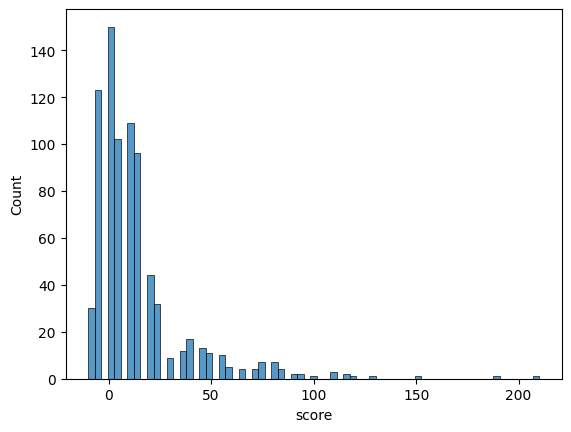

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df.score)
plt.show()

# QA7. Enriquecendo os dados

Enriqueça os dados dos imóveis com os valores dos impostos e multas municipais. Cacule a média de impostos e multas de cada grupo de vizinhaça, `neighbourhood_group`. Imóveis isentos devem ser considerados nos cálculos de média.

**Forneça os valores de média de taxas e multas para as vizinhaças do Brooklyn e
Manhattan**.



In [20]:
df_taxes = pd.read_csv(path + 'AB_NYC_2019_taxes.csv')
df_taxes.head()

,id,type,value
0,35907127,taxes,1315.0
1,804815,taxes,NaN
2,22328585,taxes,900.0
3,27876600,taxes,869.0
4,34976037,taxes,1629.0


In [21]:
df_taxes.iloc[0:4,2].mean(), df_taxes.iloc[0:4,2].sum() / len(df_taxes.iloc[0:4,2])

(np.float64(1028.0), np.float64(771.0))

In [22]:
df_taxes.fillna(0, inplace=True)
df_taxes.head()

,id,type,value
0,35907127,taxes,1315.0
1,804815,taxes,0.0
2,22328585,taxes,900.0
3,27876600,taxes,869.0
4,34976037,taxes,1629.0


In [23]:
df_taxes = pd.read_csv(path + 'AB_NYC_2019_taxes.csv')
df_taxes = pd.pivot_table(df_taxes, index='id', columns='type', values='value')

merged_df = pd.merge(df, df_taxes, on='id', how='outer')

merged_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,word,score,fines,taxes
0,20913,Charming 1 bed GR8 WBurg LOCATION!,79402,Christiana,Brooklyn,Williamsburg,40.70984,-73.95775,Entire home/apt,100,5,168,2018-07-22,1.57,1,0,others,80,796.0,789.0
1,25235,Large 2 Bedroom Great for Groups!,87773,Shelly,Brooklyn,Bedford-Stuyvesant,40.68373,-73.92377,Entire home/apt,125,90,162,2019-06-28,1.46,2,137,others,90,NaN,1779.0
2,76761,Eveland the Place to Stay & Enjoy a 5-⭐️ 2bdrm,118971,Evelyn,Brooklyn,South Slope,40.66552,-73.99019,Entire home/apt,169,2,398,2019-06-28,3.97,3,182,others,210,1935.0,1516.0
3,135465,Garden apartment close to Manhattan,663879,Christopher,Brooklyn,Fort Greene,40.68626,-73.97598,Entire home/apt,170,3,86,2019-06-20,0.91,2,286,others,50,NaN,NaN
4,169002,Modern Space in Charming Pre-war,805344,Alec,Manhattan,Harlem,40.82411,-73.94934,Private room,65,2,41,2019-06-16,0.43,2,59,others,25,NaN,NaN


In [24]:
for n in merged_df.neighbourhood_group.unique():
  print( n, merged_df[ merged_df.neighbourhood_group == n ].taxes.sum() / len(merged_df[ merged_df.neighbourhood_group == n ]) )

Brooklyn 798.4575757575758
Manhattan 855.0298913043479
Queens 793.9873417721519
Bronx 808.5
Staten Island 992.1428571428571


In [25]:
merged_df.groupby('neighbourhood_group', dropna=False)[['taxes', 'fines','id']]

In [26]:
df_group = merged_df.groupby('neighbourhood_group', dropna=False)[['taxes', 'fines','id']].agg({'taxes': 'sum', 'fines': 'sum', 'id': 'count'})
df_group['taxes_mean'] = df_group['taxes'] / df_group['id']
df_group['fines_mean'] = df_group['fines'] / df_group['id']
df_group.astype(int)


,taxes,fines,id,taxes_mean,fines_mean
neighbourhood_group,,,,,
Bronx,16170,2403,20,808,120
Brooklyn,263491,96543,330,798,292
Manhattan,314651,111503,368,855,302
Queens,62725,25176,79,793,318
Staten Island,6945,3488,7,992,498


Solução alternativa...

In [27]:
df_taxes = pd.read_csv(path + 'AB_NYC_2019_taxes.csv')
df_taxes = pd.pivot_table(df_taxes, index='id', columns='type', values='value')

merged_df = pd.merge(df, df_taxes, on='id', how='outer')
merged_df

merged_df.fillna(0, inplace=True)
merged_df.groupby('neighbourhood_group')[['taxes','fines']].mean().astype(int)

,taxes,fines
neighbourhood_group,,
Bronx,808,120
Brooklyn,798,292
Manhattan,855,302
Queens,793,318
Staten Island,992,498


In [28]:
QA7 = [('Brooklyn', 798, 292), ('Manhattan', 855, 302)] # Exemplo de Resposta (<vizinhança>, <média de taxas>, <média de multas> )

print(f'QA7: {QA7}')


QA7: [('Brooklyn', 798, 292), ('Manhattan', 855, 302)]


Note, o inner join leva a valores errados.

In [29]:
df_taxes = pd.read_csv(path + 'AB_NYC_2019_taxes.csv')
df_taxes = pd.pivot_table(df_taxes, index='id', columns='type', values='value')

merged_df = pd.merge(df, df_taxes, on='id')

merged_df.groupby('neighbourhood_group',dropna=False)[['taxes','fines']].mean().astype(int)

,taxes,fines
neighbourhood_group,,
Bronx,1078,1201
Brooklyn,1126,975
Manhattan,1073,1103
Queens,980,1007
Staten Island,1389,1744


# QA8. ZipCodes, um "join" diferente,

Considere a base de dados de zip codes dos Estados Unidos abaixo. Queremos empregar esses dados para enriquecer a base de dados df do Airbnb acrescentando os campos 'zip', 'zip_city', 'zip_state_id_zip' da tabela zips como mostrado abaixo. As cidades, entranto, não são compatíveis entre as bases e não é possível fazer um join. Assim, você precisará empregar o zip code de localização mais próxima que encontrar.

Você pode verificar que mais de 50% dos nomes de cidade (`neighbourhood_group`) não batem com a cidade fornecida pela tabela de zip codes.

1. **Forneça na sua resposta o dataframe df enriquecido com os dados de zip codes pedidos acima.**
2. **Qual o nome de cidade pode ser *unificado* (que se encontra de uma forma na tabela Airbnb e de outra na tabela de zips), ajustando-se a base de dados e reduzindo a discrepância dos nomes de cidades para cerca de 10%.**



In [30]:
df_zip = pd.read_csv(path + 'uszips.csv')
df_zip.head()

,zip,lat,lng,city,state_id,state_name,zcta,parent_zcta,population,density,county_fips,county_name,county_weights,county_names_all,county_fips_all,imprecise,military,timezone
0,601,18.18027,-66.75266,Adjuntas,PR,Puerto Rico,True,NaN,16669.0,99.9,72001,Adjuntas,"{""72001"": 98.74, ""72141"": 1.26}",Adjuntas|Utuado,72001|72141,False,False,America/Puerto_Rico
1,602,18.36075,-67.17541,Aguada,PR,Puerto Rico,True,NaN,37233.0,474.0,72003,Aguada,"{""72003"": 100}",Aguada,72003,False,False,America/Puerto_Rico
2,603,18.45744,-67.12225,Aguadilla,PR,Puerto Rico,True,NaN,48448.0,544.6,72005,Aguadilla,"{""72005"": 99.76, ""72099"": 0.24}",Aguadilla|Moca,72005|72099,False,False,America/Puerto_Rico
3,606,18.16585,-66.93716,Maricao,PR,Puerto Rico,True,NaN,5163.0,45.0,72093,Maricao,"{""72093"": 82.26, ""72153"": 11.67, ""72121"": 6.06}",Maricao|Yauco|Sabana Grande,72093|72153|72121,False,False,America/Puerto_Rico
4,610,18.29110,-67.12243,Anasco,PR,Puerto Rico,True,NaN,25357.0,263.8,72011,Añasco,"{""72011"": 96.8, ""72099"": 2.83, ""72083"": 0.37}",Añasco|Moca|Las Marías,72011|72099|72083,False,False,America/Puerto_Rico


In [31]:
def get_zip(lat,lng,df_zip):
  ind = np.sqrt( (df_zip.lat - lat)**2 + (df_zip.lng - lng)**2 ).idxmin()
  return df_zip.iloc[ind].zip, df_zip.iloc[ind].lat, df_zip.iloc[ind].lng, df_zip.iloc[ind].city, df_zip.iloc[ind].state_id

zip, zip_lat, zip_lng, zip_city, zip_state_id_zip = get_zip(df.iloc[0].latitude,df.iloc[0].longitude,df_zip)

zip, zip_lat, zip_lng, zip_city, zip_state_id_zip

(np.int64(11249),
 np.float64(40.71121),
 np.float64(-73.96318),
 'Brooklyn',
 'NY')

In [32]:
new_cols = df.apply(lambda x: get_zip(x['latitude'], x['longitude'], df_zip), axis=1, result_type='expand')
df[['zip', 'zip_lat', 'zip_lng', 'zip_city', 'zip_state_id_zip']] = new_cols

# display(df[['id', 'latitude', 'longitude', 'zip', 'zip_city', 'zip_state_id_zip']].head())
display(df.drop(columns=['latitude','longitude']).head())

# Veja os campos zip_* adicionados no final do dataframe

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,...,reviews_per_month,calculated_host_listings_count,availability_365,word,score,zip,zip_lat,zip_lng,zip_city,zip_state_id_zip
0,20913,Charming 1 bed GR8 WBurg LOCATION!,79402,Christiana,Brooklyn,Williamsburg,Entire home/apt,100,5,168,...,1.57,1,0,others,80,11249,40.71121,-73.96318,Brooklyn,NY
1,25235,Large 2 Bedroom Great for Groups!,87773,Shelly,Brooklyn,Bedford-Stuyvesant,Entire home/apt,125,90,162,...,1.46,2,137,others,90,11233,40.67827,-73.91994,Brooklyn,NY
2,76761,Eveland the Place to Stay & Enjoy a 5-⭐️ 2bdrm,118971,Evelyn,Brooklyn,South Slope,Entire home/apt,169,2,398,...,3.97,3,182,others,210,11215,40.66255,-73.98687,Brooklyn,NY
3,135465,Garden apartment close to Manhattan,663879,Christopher,Brooklyn,Fort Greene,Entire home/apt,170,3,86,...,0.91,2,286,others,50,11217,40.68242,-73.97943,Brooklyn,NY
4,169002,Modern Space in Charming Pre-war,805344,Alec,Manhattan,Harlem,Private room,65,2,41,...,0.43,2,59,others,25,10031,40.82485,-73.95023,New York,NY


In [33]:
df['neighbourhood_group'].unique(), df['zip_city'].unique()

(array(['Brooklyn', 'Manhattan', 'Queens', 'Bronx', 'Staten Island'],
       dtype=object),
 array(['Brooklyn', 'New York', 'Astoria', 'Sunnyside', 'Long Island City',
        'Bronx', 'Springfield Gardens', 'Rego Park', 'Middle Village',
        'Flushing', 'Far Rockaway', 'Queens Village', 'East Elmhurst',
        'Cambria Heights', 'Oakland Gardens', 'Staten Island',
        'Little Neck', 'Ridgewood', 'Woodside', 'Rockaway Park',
        'Jackson Heights', 'Arverne', 'Jamaica', 'Elmhurst', 'Ozone Park',
        'Whitestone', 'Mount Vernon', 'Bayside', 'Hollis', 'Forest Hills'],
       dtype=object))

In [34]:
df[['neighbourhood_group','zip_city']]

,neighbourhood_group,zip_city
0,Brooklyn,Brooklyn
1,Brooklyn,Brooklyn
2,Brooklyn,Brooklyn
3,Brooklyn,Brooklyn
4,Manhattan,New York
...,...,...
799,Brooklyn,Brooklyn
800,Queens,Sunnyside
801,Brooklyn,Brooklyn
802,Brooklyn,Brooklyn


In [35]:
df[ df['neighbourhood_group'] != df['zip_city'] ].neighbourhood_group.value_counts().sum() / len(df)

np.float64(0.5634328358208955)

In [36]:
df['neighbourhood_group'] = df['neighbourhood_group'].replace('Manhattan','New York')


In [37]:
df[ df['neighbourhood_group'] != df['zip_city'] ].neighbourhood_group.value_counts().sum() / len(df)

np.float64(0.10572139303482588)

In [39]:
# Exemplo de Resposta
# 1
QA8df = df.copy()
# 2
QA8 = 'Manhattan' # nome da cidade que de ser unificado, exemplo de resposta

# QA8 = 'New York' # alternativamente...

print(f'QA8: {QA8}')
display(QA8df.head())

QA8: Manhattan


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,reviews_per_month,calculated_host_listings_count,availability_365,word,score,zip,zip_lat,zip_lng,zip_city,zip_state_id_zip
0,20913,Charming 1 bed GR8 WBurg LOCATION!,79402,Christiana,Brooklyn,Williamsburg,40.70984,-73.95775,Entire home/apt,100,...,1.57,1,0,others,80,11249,40.71121,-73.96318,Brooklyn,NY
1,25235,Large 2 Bedroom Great for Groups!,87773,Shelly,Brooklyn,Bedford-Stuyvesant,40.68373,-73.92377,Entire home/apt,125,...,1.46,2,137,others,90,11233,40.67827,-73.91994,Brooklyn,NY
2,76761,Eveland the Place to Stay & Enjoy a 5-⭐️ 2bdrm,118971,Evelyn,Brooklyn,South Slope,40.66552,-73.99019,Entire home/apt,169,...,3.97,3,182,others,210,11215,40.66255,-73.98687,Brooklyn,NY
3,135465,Garden apartment close to Manhattan,663879,Christopher,Brooklyn,Fort Greene,40.68626,-73.97598,Entire home/apt,170,...,0.91,2,286,others,50,11217,40.68242,-73.97943,Brooklyn,NY
4,169002,Modern Space in Charming Pre-war,805344,Alec,New York,Harlem,40.82411,-73.94934,Private room,65,...,0.43,2,59,others,25,10031,40.82485,-73.95023,New York,NY


# QA9. Quebras

Construa no `Pandas` um "relatório" (`df_report`) como abaixo. Os valores são ordenados `neighbourhood_group`,`neighbourhood`. Cada "página" contém apenas 30 linhas. A cada "quebra" de `neighbourhood_group` é gerada uma linha com preço médio do `neighbourhood_group` e, então, é iniciada uma nova página.

O item `line_id` é opcional mas deve auxiliá-lo nessa tarefa.

Forneça para resposta o dataframe `df_report` gerado.

In [40]:
df = df.sort_values(['neighbourhood_group','neighbourhood']).reset_index(drop=True)

previous_neighbourhood_group = None
df_report = pd.DataFrame({'neighbourhood_group':[],'neighbourhood':[],'price':[],'page_id':[],'line_id':[]})
page_id = 1
line_id = 1
for ix, row in df.iterrows():
  if line_id > 30:
    line_id = 1
    page_id += 1

  if previous_neighbourhood_group != row.neighbourhood_group and previous_neighbourhood_group is not None:
    df_report.loc[len(df_report)] = previous_neighbourhood_group, 'MEAN', df[ df.neighbourhood_group == previous_neighbourhood_group ].price.mean(), page_id, line_id
    page_id += 1
    line_id = 1

  df_report.loc[len(df_report)] = row.neighbourhood_group, row.neighbourhood, row.price, page_id, line_id
  line_id += 1

  previous_neighbourhood_group = row.neighbourhood_group

df_report.loc[len(df_report)] = row.neighbourhood_group, 'MEAN', df[ df.neighbourhood_group == previous_neighbourhood_group ].price.mean(), page_id, line_id

df_report

,neighbourhood_group,neighbourhood,price,page_id,line_id
0,Bronx,Belmont,29.000000,1,1
1,Bronx,Claremont Village,67.000000,1,2
2,Bronx,Concourse,40.000000,1,3
3,Bronx,Edenwald,90.000000,1,4
4,Bronx,Edenwald,80.000000,1,5
...,...,...,...,...,...
804,Staten Island,South Beach,100.000000,30,4
805,Staten Island,St. George,130.000000,30,5
806,Staten Island,Todt Hill,135.000000,30,6
807,Staten Island,Tompkinsville,59.000000,30,7


Algumas checagens...

In [41]:
df_summary = df_report[ df_report.neighbourhood == 'MEAN' ].reset_index(drop=True)
page_previous = 0
df_summary['qty'] = 0

for i in range(len(df_summary)):
    df_summary.loc[i,'qty'] = (df_summary.loc[i,'page_id'] - page_previous - 1)*30 + df_summary.loc[i,'line_id'] - 1
    page_previous = df_summary.loc[i,'page_id']

df_summary

,neighbourhood_group,neighbourhood,price,page_id,line_id,qty
0,Bronx,MEAN,71.500000,1,21,20
1,Brooklyn,MEAN,128.087879,13,1,330
2,New York,MEAN,196.157609,26,9,368
3,Queens,MEAN,92.227848,29,20,79
4,Staten Island,MEAN,89.428571,30,8,7


In [42]:
df.groupby(['neighbourhood_group']).price.agg(['mean','count'])

,mean,count
neighbourhood_group,,
Bronx,71.500000,20
Brooklyn,128.087879,330
New York,196.157609,368
Queens,92.227848,79
Staten Island,89.428571,7


Somas...

In [43]:
sum_price_pages = df_report[ df_report.page_id.isin([1,24,25,28]) ].groupby('page_id').price.sum().astype(int).sum()

print(f'A soma dos preços das páginas 1, 24, 25 e 28 é: {sum_price_pages}')

A soma dos preços das páginas 1, 24, 25 e 28 é: 12633


In [44]:
sum_price_pages = df_report[ df_report.page_id.isin([1,24,25,26,28]) ].groupby('page_id').price.sum().astype(int).sum()

print(f'A soma dos preços das páginas 1, 24, 25, 26 e 28 é: {sum_price_pages}')

A soma dos preços das páginas 1, 24, 25, 26 e 28 é: 17838


Você pode verificar alguns checks...

In [45]:
df_report.iloc[-10::,:]

,neighbourhood_group,neighbourhood,price,page_id,line_id
799,Queens,Woodside,120.000000,29,19
800,Queens,MEAN,92.227848,29,20
801,Staten Island,Arden Heights,83.000000,30,1
802,Staten Island,Randall Manor,99.000000,30,2
803,Staten Island,South Beach,20.000000,30,3
804,Staten Island,South Beach,100.000000,30,4
805,Staten Island,St. George,130.000000,30,5
806,Staten Island,Todt Hill,135.000000,30,6
807,Staten Island,Tompkinsville,59.000000,30,7
808,Staten Island,MEAN,89.428571,30,8


In [46]:
df_report.iloc[0:32,:]

,neighbourhood_group,neighbourhood,price,page_id,line_id
0,Bronx,Belmont,29.0,1,1
1,Bronx,Claremont Village,67.0,1,2
2,Bronx,Concourse,40.0,1,3
3,Bronx,Edenwald,90.0,1,4
4,Bronx,Edenwald,80.0,1,5
5,Bronx,Fieldston,85.0,1,6
6,Bronx,Fieldston,109.0,1,7
7,Bronx,Fordham,79.0,1,8
8,Bronx,Highbridge,22.0,1,9
9,Bronx,Melrose,69.0,1,10


In [47]:
QA9 = df_report.copy() # Exemplo de Resposta

print(f'QA9:')
display(QA9)

QA9:


,neighbourhood_group,neighbourhood,price,page_id,line_id
0,Bronx,Belmont,29.000000,1,1
1,Bronx,Claremont Village,67.000000,1,2
2,Bronx,Concourse,40.000000,1,3
3,Bronx,Edenwald,90.000000,1,4
4,Bronx,Edenwald,80.000000,1,5
...,...,...,...,...,...
804,Staten Island,South Beach,100.000000,30,4
805,Staten Island,St. George,130.000000,30,5
806,Staten Island,Todt Hill,135.000000,30,6
807,Staten Island,Tompkinsville,59.000000,30,7


# **Case 2**: CNN news

Neste case analise comentários de notícias postados pelo canal CNN.


In [48]:
df = pd.read_csv(path + 'Cleaned_cnn_comments.csv')
df.head()

,comment_text,likes,comment_time
0,"Just like US did not abandon Vietnam, Iraq, Af...",73,7200.0
1,Anybody else getting tired of these people spe...,193,7200.0
2,"""If two fish are fighting in a river an Englis...",45,7200.0
3,"""Not abandon"" is not equal to ""Defend/no fly-z...",7,7200.0
4,It's time we pray that our world leaders get a...,52,7200.0


# QB1. Temas mais frequentes nos posts CNN

Verifique os posts da CNN que contenham os **nomes próprios**

```
'USA','US','Russia','Ukraine','Cuba','Israel','Trump'
```

Como são posts, os nomes podem ocorrer com letras minúsculas. Mas considere somente os nomes próprios.

Qual o percentual de posts apresentam **nomes**?

In [49]:
regex_pattern = ''

words_to_match = ['usa','us','russia','ukraine','cuba','israel','trump']

for i, w in enumerate(words_to_match):
  regex_pattern += r'\b' + w + r'\b'
  if i < len(words_to_match) - 1:
   regex_pattern += '|'

print(f"A expressão regular é: {regex_pattern}")

df.comment_text.str.lower().str.contains(regex_pattern).sum() / len(df)

A expressão regular é: \busa\b|\bus\b|\brussia\b|\bukraine\b|\bcuba\b|\bisrael\b|\btrump\b


np.float64(0.1948343627175744)

In [50]:
QB1 = 19.48 # Exemplo de Resposta

print(f'QB1: {QB1} %')

QB1: 19.48 %


# QB2. Posts com mais "Likes"

Considerando somente os posts com os nomes próprios selecionados no exercício anterior, **quais apresentam maior quantidade de likes?**. Forneça os 3 com mais Likes e as respectivas quantidades de likes.

In [51]:
def change_stringK2value(s):

  if s.find('K') > 0:
    s = s.replace('K','')
    value = float(s) * 1000
  else:
    value = float(s)

  return value

df['likes_numeric'] = df.likes.apply(lambda s: change_stringK2value(s))

In [52]:
df[ df.comment_text.str.lower().str.contains(regex_pattern) ].nlargest(5,'likes_numeric')

,comment_text,likes,comment_time,likes_numeric
13351,Trump making fun of someone else's weight is ...,2.8K,504.0,2800.0
1051,The comparison between this man and Trump is…b...,2.7K,216.0,2700.0
6448,"According to Russky sources ,the blast killed ...",1.7K,288.0,1700.0
12003,The worst thing about Trump isn't what we've l...,1.3K,336.0,1300.0
12009,One of the worst parts of the Trump era is the...,1.3K,336.0,1300.0


In [53]:
regex_pattern = ''

words = ['usa','us','russia','ukraine','cuba','israel','trump']

df_group = pd.DataFrame()

for i, w in enumerate(words):
  regex_pattern = r'\b' + w + r'\b'
  # df_group.loc[w,'count'] = df[ df.comment_text.str.lower().str.contains(regex_pattern) ].shape[0]
  df_group.loc[w,'likes_sum'] = df[ df.comment_text.str.lower().str.contains(regex_pattern) ].likes_numeric.sum()
  # print(w, df[ df.comment_text.str.lower().str.contains(regex_pattern) ].likes_numeric.sum())

df_group.sort_values('likes_sum',ascending=False)

,likes_sum
trump,52460.0
ukraine,18241.0
us,15086.0
russia,12662.0
usa,1606.0
cuba,49.0
israel,12.0


In [54]:
QB2= [('trump', 52460), ('ukraine', 18241), ('us', 15086)] # Exemplo de Resposta

print(f'QB1: {QB2} %')

QB1: [('trump', 52460), ('ukraine', 18241), ('us', 15086)] %


# Respostas

In [55]:
#@markdown Execute para gerar e verificar suas respostas
import pickle
import numpy as np
import pandas as pd

df_sample = pd.read_csv('/content/sample_data/california_housing_train.csv')

x = np.pi
np_array_3d = np.random.rand(3, 3, 3) # Example 3x3x3 numpy array

# Create an example dictionary with complex objects
example_dict = {
    'QA1': QA1,
    'QA2': QA2,
    'QA3': QA3,
    'QA4': QA4,
    'QA5': QA5,
    'QA6': QA6,
    'QA6B': QA6B,
    'QA7': QA7,
    'QA8': QA8,
    'QA8df': QA8df,
    'QA9': QA9,
    'QB1': QB1,
    'QB2': QB2,
}

# Define the filename with .pkl extension
filename = 'P1_' + Nome.replace(' ','_') + '_' + RA + '.pkl'

# Serialize the dictionary to a pickle file
with open(filename, 'wb') as f:
    pickle.dump(example_dict, f)

from IPython.display import display, HTML

# display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
display(HTML('<span style="font-size: 24px; color: blue;">Respostas</span>'))
print()
for key, value in example_dict.items():
  if key != 'QA9' and key != 'QA8df' and key != 'QA6':
    print(f'{key}: {value}')
  if key == 'QA9':
    print(f'{key}:')
    try:
      display(value.head())
    except:
      display('None')
  if key == 'QA8df':
    print(f'{key}:')
    try:
      display(value[['id', 'zip', 'zip_city', 'zip_state_id_zip']].head())
    except:
      display('None')
  if key == 'QA6':
    print(f'{key}:')
    try:
      display(np.array(value[0:10]))
    except:
      display('None')
  print()

print()
display(HTML('<span style="font-size: 14px; color: blue;">Respostas salvas com sucesso em:</span>'))
print()
fname = f'<span style="font-size: 14px; color: blue;"><strong>{filename}</strong></span>'
display(HTML(fname))


QA1: [('Sonder (NYC)', 7), ('Kara', 4), ('Stanley', 4)]

QA2: 67.81

QA3: 151.42

QA4: 10.05

QA5: [('heart', 36, 166.38), ('beautiful', 41, 137.92), ('sunny', 43, 137.67)]

QA6:


array([ 80,  90, 210,  50,  25,  10,  45, 120,   0,   0])


QA6B: 10955

QA7: [('Brooklyn', 798, 292), ('Manhattan', 855, 302)]

QA8: Manhattan

QA8df:


,id,zip,zip_city,zip_state_id_zip
0,20913,11249,Brooklyn,NY
1,25235,11233,Brooklyn,NY
2,76761,11215,Brooklyn,NY
3,135465,11217,Brooklyn,NY
4,169002,10031,New York,NY



QA9:


,neighbourhood_group,neighbourhood,price,page_id,line_id
0,Bronx,Belmont,29.0,1,1
1,Bronx,Claremont Village,67.0,1,2
2,Bronx,Concourse,40.0,1,3
3,Bronx,Edenwald,90.0,1,4
4,Bronx,Edenwald,80.0,1,5



QB1: 19.48

QB2: [('trump', 52460), ('ukraine', 18241), ('us', 15086)]




In [56]:
#@markdown Execute para fazer o download do arquivo com suas respostas
from google.colab import files
files.download(filename)


fname = f'<span style="font-size: 14px; color: blue;">Salve o arquivo {filename} para download.</strong></span>'
display(HTML(fname))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>